In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("banking_fraud_dataset.csv")
df.head()


,Transaction_ID,Customer_ID,Account_Number,Transaction_Date,Transaction_Time,Transaction_Type,Amount,Merchant,Merchant_Category,Province,...,Card_Present,International,Previous_24hr_Transactions,Previous_24hr_Amount,Account_Age_Months,Customer_Age,Risk_Score,Fraud_Indicators,Fraud_Flag,Fraud_Type
0,T0000001,C00997,****1954,2025-02-08,05:00:00,Deposit,4376.75,Checkers,Grocery,Gauteng,...,Yes,No,10,1735.73,110,24,17,NaN,No,NaN
1,T0000002,C01088,****5947,2025-11-03,19:01:00,ATM Withdrawal,3233.82,Eskom,Utilities,Gauteng,...,Yes,No,1,17253.84,214,48,67,NaN,No,NaN
2,T0000003,C01104,****4837,2025-02-18,20:04:00,ATM Withdrawal,2503.82,Takealot,Electronics,Gauteng,...,No,No,12,17674.85,56,71,63,NaN,No,NaN
3,T0000004,C00274,****6313,2025-05-06,13:58:00,Deposit,1880.85,Takealot,Electronics,Gauteng,...,Yes,No,19,5797.62,150,51,26,NaN,No,NaN
4,T0000005,C00798,****2975,2025-02-18,17:34:00,Bill Payment,4136.88,Checkers,Grocery,Gauteng,...,Yes,No,0,14895.33,45,47,61,NaN,No,NaN


In [149]:
df.describe()

,Amount,Previous_24hr_Transactions,Previous_24hr_Amount,Account_Age_Months,Customer_Age,Risk_Score
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,3723.342234,9.88400,10080.755760,119.999000,48.369600,36.400800
std,7993.497888,6.04922,5739.084142,69.164472,18.288343,21.488809
min,20.940000,0.00000,1.480000,1.000000,18.000000,1.000000
25%,1346.557500,5.00000,5222.302500,60.000000,32.000000,18.000000
50%,2637.030000,10.00000,10113.280000,120.000000,48.000000,36.000000
75%,3856.220000,15.00000,15101.282500,179.000000,65.000000,54.000000
max,79452.100000,20.00000,19993.430000,240.000000,80.000000,100.000000


In [150]:
df.isnull().sum()

,0
Transaction_ID,0
Customer_ID,0
Account_Number,0
Transaction_Date,0
Transaction_Time,0
Transaction_Type,0
Amount,0
Merchant,0
Merchant_Category,0
Province,0


In [151]:
df.duplicated().sum()

np.int64(0)

In [152]:
# Replace missing values with "No Fraud"

df["Fraud_Indicators"] = df["Fraud_Indicators"].fillna("No Fraud")

df["Fraud_Type"] = df["Fraud_Type"].fillna("No Fraud")

print("Missing values handled successfully!")

Missing values handled successfully!


In [153]:
# Count fraud and non-fraud transactions
df["Fraud_Flag"].value_counts()

,count
Fraud_Flag,
No,4857
Yes,143


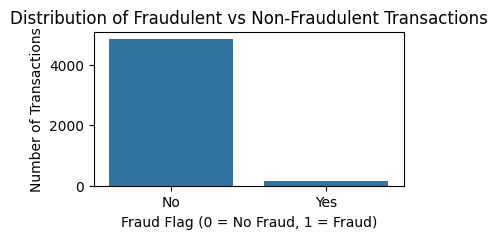

In [154]:
#Fraud Distribution Visualz

plt.figure(figsize=(4,2))

sns.countplot(data=df, x="Fraud_Flag")
plt.title("Distribution of Fraudulent vs Non-Fraudulent Transactions")
plt.xlabel("Fraud Flag (0 = No Fraud, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

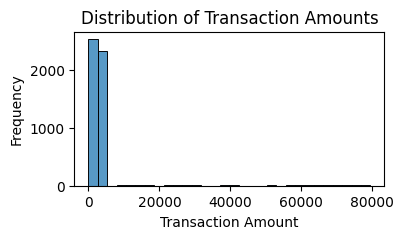

In [155]:
#Transactional Amount Distribution

plt.figure(figsize=(4,2))

sns.histplot(df["Amount"], bins=30)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

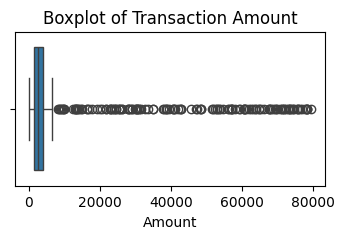

In [156]:
#Boxplot of Transaction Amount
plt.figure(figsize=(4,2))

sns.boxplot(x=df["Amount"])
plt.title("Boxplot of Transaction Amount")

plt.show()

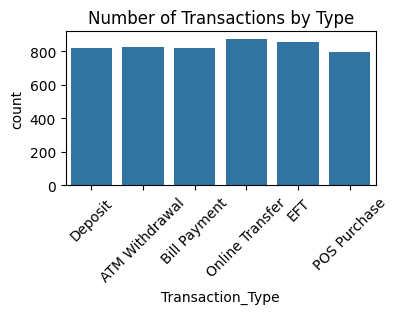

In [157]:
#Transaction Type

df["Transaction_Type"].value_counts()
plt.figure(figsize=(4,2))

sns.countplot(data=df, x="Transaction_Type")
plt.title("Number of Transactions by Type")
plt.xticks(rotation=45)

plt.show()

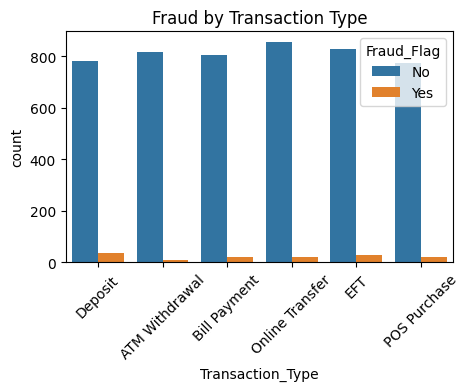

In [158]:
#Fraud By Transaction Type

plt.figure(figsize=(5,3))

sns.countplot(data=df,
              x="Transaction_Type",
              hue="Fraud_Flag")

plt.title("Fraud by Transaction Type")
plt.xticks(rotation=45)

plt.show()

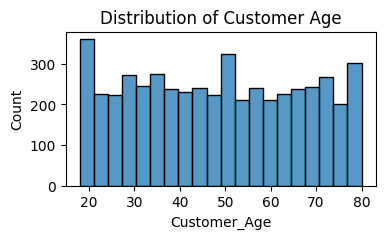

In [159]:
#Customer Age Distribution

plt.figure(figsize=(4,2))

sns.histplot(df["Customer_Age"], bins=20)

plt.title("Distribution of Customer Age")

plt.show()

In [160]:
# Selecting only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Displaying  the first few rows
numeric_df.head()

,Amount,Previous_24hr_Transactions,Previous_24hr_Amount,Account_Age_Months,Customer_Age,Risk_Score
0,4376.75,10,1735.73,110,24,17
1,3233.82,1,17253.84,214,48,67
2,2503.82,12,17674.85,56,71,63
3,1880.85,19,5797.62,150,51,26
4,4136.88,0,14895.33,45,47,61


In [161]:
# Calculating the correlation matrix
correlation_matrix = numeric_df.corr()

# Displaying it
correlation_matrix

,Amount,Previous_24hr_Transactions,Previous_24hr_Amount,Account_Age_Months,Customer_Age,Risk_Score
Amount,1.000000,-0.009204,-0.008270,0.013068,-0.008822,0.333307
Previous_24hr_Transactions,-0.009204,1.000000,0.005467,-0.003718,-0.000538,0.008943
Previous_24hr_Amount,-0.008270,0.005467,1.000000,0.024338,-0.007245,-0.018023
Account_Age_Months,0.013068,-0.003718,0.024338,1.000000,-0.016461,0.019599
Customer_Age,-0.008822,-0.000538,-0.007245,-0.016461,1.000000,-0.011515
Risk_Score,0.333307,0.008943,-0.018023,0.019599,-0.011515,1.000000


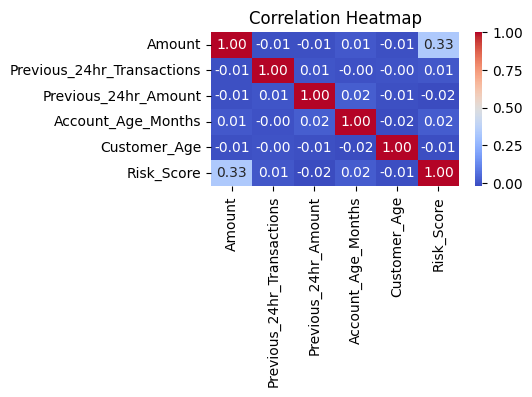

In [162]:
plt.figure(figsize=(4,2))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [163]:
# Count fraudulent and non-fraudulent transactions

df["Fraud_Flag"].value_counts()

,count
Fraud_Flag,
No,4857
Yes,143


In [164]:
#AVG fraud Amount by Status
df.groupby("Fraud_Flag")["Amount"].mean()

,Amount
Fraud_Flag,
No,2538.966605
Yes,43950.701888


In [165]:
#Fraud by Transaction Type
pd.crosstab(df["Transaction_Type"], df["Fraud_Flag"])

Fraud_Flag,No,Yes
Transaction_Type,,
ATM Withdrawal,818,11
Bill Payment,803,20
Deposit,782,38
EFT,828,29
Online Transfer,853,22
POS Purchase,773,23


In [166]:
merchant_fraud = pd.crosstab(df["Merchant_Category"],
                             df["Fraud_Flag"])

merchant_fraud

Fraud_Flag,No,Yes
Merchant_Category,,
Electronics,983,29
Fuel,982,26
Grocery,1944,66
Utilities,948,22


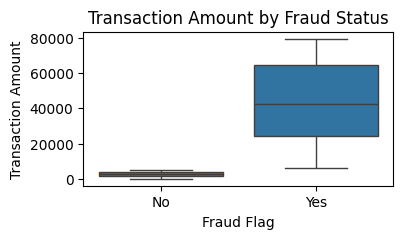

In [167]:
plt.figure(figsize=(4,2))

sns.boxplot(data=df,
            x="Fraud_Flag",
            y="Amount")

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud Flag")
plt.ylabel("Transaction Amount")

plt.show()

In [168]:
#Which transaction types have the highest average transaction amount?

transaction_avg = df.groupby("Transaction_Type")["Amount"].mean().sort_values(ascending=False)

transaction_avg

,Amount
Transaction_Type,
Deposit,4301.254732
EFT,4114.881680
POS Purchase,3855.955389
Online Transfer,3503.435211
Bill Payment,3491.604690
ATM Withdrawal,3081.775308


In [170]:
df.to_csv("cleaned_banking_fraud.csv", index=False)

print("✅ Cleaned dataset saved successfully!")

✅ Cleaned dataset saved successfully!


In [171]:
from google.colab import files

files.download("cleaned_banking_fraud.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>